# Overlap Sweep: Iris Binary (versicolor vs virginica)

**What this notebook does:**
1. Loads Iris, drops setosa → binary classification: versicolor (−1) vs virginica (+1)
2. Adds 150 points per class following Iris distribution
3. Adds 50 synthetic points per class at 4 overlap levels: `0.1, 0.2, 0.3, 0.4`
4. For each dataset: trains a **SVM** and a **VQC (clean simulator)**
5. Evaluates each trained model on 3 conditions:
   - `sim → sim` : clean weights, clean evaluation (upper bound)
   - `sim → noisy` : clean weights, noisy Aer evaluation (degradation signal)
   - `SVM` : classical baseline
6. Plots different metrics across all conditions


## 1. Imports & Configuration

In [ ]:
import os
import json
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Circuit
N_QUBITS   = 4
N_LAYERS   = 7
N_FEATURES = 4
SHOTS_HW   = 512

# Training
LEARNING_RATE = 0.05
N_EPOCHS      = 50
BATCH_SIZE    = 16

MODELS_DIR = "models_overlap"
os.makedirs(MODELS_DIR, exist_ok=True)

# Overlap levels to sweep
OVERLAP_LEVELS = [0.1, 0.2, 0.3, 0.4]
N_SYNTHETIC    = 50   # synthetic points added per class per overlap level

IBM_TOKEN = "ibm token"

print(f"PennyLane {qml.__version__}")
print(f"N_LAYERS={N_LAYERS}  SHOTS_HW={SHOTS_HW}")
print(f"Overlap sweep: {OVERLAP_LEVELS}  |  {N_SYNTHETIC} synthetic pts/class")


PennyLane 0.44.1
N_LAYERS=7  SHOTS_HW=512
Overlap sweep: [0.1, 0.2, 0.3, 0.4]  |  50 synthetic pts/class


## 2. IBM Backend & Noise Model

In [21]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN
)

backends = service.backends(simulator=False, operational=True)
print([b.name for b in backends])


qiskit_runtime_service._discover_account:WARNING:2026-06-12 12:12:38,312: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-12 12:12:40,902: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QML. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-12 12:12:40,904: Loading instance: QML, plan: open


['ibm_fez', 'ibm_marrakesh', 'ibm_kingston']


In [22]:
ibm_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(ibm_backend)
print(f"Noise model loaded from: {ibm_backend.name}")

qiskit_runtime_service.backends:WARNING:2026-06-12 12:13:27,899: Using instance: QML, plan: open


Noise model loaded from: ibm_fez


## 3. Dataset Construction

**Binary task:** versicolor (class 1 → label −1) vs virginica (class 2 → label +1).  
Setosa is dropped — it is trivially separable and contributes nothing to the noise sensitivity study.

For each `overlap_std` in `[0.1, 0.2, 0.3, 0.4]`, we:
1. Start from the 100 real samples (50 versicolor + 50 virginica)
2. Compute the centroid of each class in the **scaled** feature space
3. Compute the midpoint between the two centroids
4. Sample `N_SYNTHETIC` points per class from a Gaussian centered at the midpoint  
   with std = `overlap_std` — these land directly in the decision boundary region
5. Split 70/30 train/test, stratified

The synthetic points are **identical across overlap levels except for the std**, so the
only variable is how much the classes bleed into each other.


In [23]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
import pandas as pd

def augment_with_copula(X_scaled, y_binary, n_per_class=150, seed=SEED):
    """
    Generate n_per_class samples per class ussing Gaussian Copula,
    using original distribution and correlations of Iris.
    """
    feature_cols = ['f0', 'f1', 'f2', 'f3']
    df = pd.DataFrame(X_scaled, columns=feature_cols)
    df['label'] = y_binary

    augmented_X, augmented_y = [X_scaled.copy()], [y_binary.copy()]

    for cls in [-1, 1]:
        subset = df[df['label'] == cls][feature_cols].reset_index(drop=True)

        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(subset)

        synth = GaussianCopulaSynthesizer(
            metadata,
            default_distribution='norm',
            enforce_min_max_values=True   # respeta el rango [0, π] automáticamente
        )
        synth.fit(subset)
        syn_df = synth.sample(num_rows=n_per_class)

        augmented_X.append(syn_df[feature_cols].values)
        augmented_y.append(np.full(n_per_class, float(cls)))

    return np.vstack(augmented_X), np.concatenate(augmented_y)


def build_binary_iris_datasets(overlap_levels, n_copula=150, n_synthetic=50, seed=SEED):
    """
    Step 1 — Copula: add n_copula samples per clase with Iris real distribution.
    Step 2 — Overlap: add n_synthetic samples per clase in decition frontier with controled std.

    Total per dataset: 100 real + 2×150 copula + 2×50 overlap
    """
    iris   = load_iris()
    mask   = iris.target != 0
    X_raw  = iris.data[mask].astype(np.float64)
    y_raw  = iris.target[mask]

    scaler   = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_raw)
    y_binary = np.where(y_raw == 2, 1, -1).astype(np.float64)

    # Paso 1: aumentar con copula — igual para todos los overlap levels
    # Se hace una sola vez fuera del loop porque no depende de std
    print("  Fitting Gaussian Copula...")
    X_base, y_base = augment_with_copula(X_scaled, y_binary,
                                          n_per_class=n_copula, seed=seed)
    print(f"  Base dataset after copula: {len(X_base)} samples "
          f"({int((y_base==1).sum())} pos, {int((y_base==-1).sum())} neg)")

    rng      = np.random.default_rng(seed)
    datasets = {}

    for std in overlap_levels:
        # Paso 2: añadir overlap en la frontera — varía por std
        c_neg    = X_base[y_base == -1].mean(axis=0)
        c_pos    = X_base[y_base ==  1].mean(axis=0)
        midpoint = (c_neg + c_pos) / 2
        offset   = (c_pos - c_neg) * 0.1

        syn_neg = rng.normal(loc=midpoint - offset, scale=std, size=(n_synthetic, N_FEATURES))
        syn_pos = rng.normal(loc=midpoint + offset, scale=std, size=(n_synthetic, N_FEATURES))
        syn_neg = np.clip(syn_neg, 0, np.pi)
        syn_pos = np.clip(syn_pos, 0, np.pi)

        X_aug = np.vstack([X_base, syn_neg, syn_pos])
        y_aug = np.concatenate([y_base,
                                np.full(n_synthetic, -1.0),
                                np.full(n_synthetic,  1.0)])

        X_train, X_test, y_train, y_test = train_test_split(
            X_aug, y_aug, test_size=0.3, random_state=seed, stratify=y_aug
        )
        datasets[std] = {
            "X_train": X_train, "y_train": y_train,
            "X_test" : X_test,  "y_test" : y_test,
            "n_total": len(X_aug),
            "scaler" : scaler,
        }
        print(f"  overlap={std:.2f}  total={len(X_aug)}  "
              f"train={len(X_train)}  test={len(X_test)}  "
              f"pos_train={int((y_train==1).sum())}  neg_train={int((y_train==-1).sum())}")

    return datasets

print("Building datasets for each overlap level...")
datasets = build_binary_iris_datasets(OVERLAP_LEVELS)

Building datasets for each overlap level...
  Fitting Gaussian Copula...
  Base dataset after copula: 400 samples (200 pos, 200 neg)
  overlap=0.10  total=500  train=350  test=150  pos_train=175  neg_train=175
  overlap=0.20  total=500  train=350  test=150  pos_train=175  neg_train=175
  overlap=0.30  total=500  train=350  test=150  pos_train=175  neg_train=175
  overlap=0.40  total=500  train=350  test=150  pos_train=175  neg_train=175


## 4. Visualise Datasets — Overlap Sweep

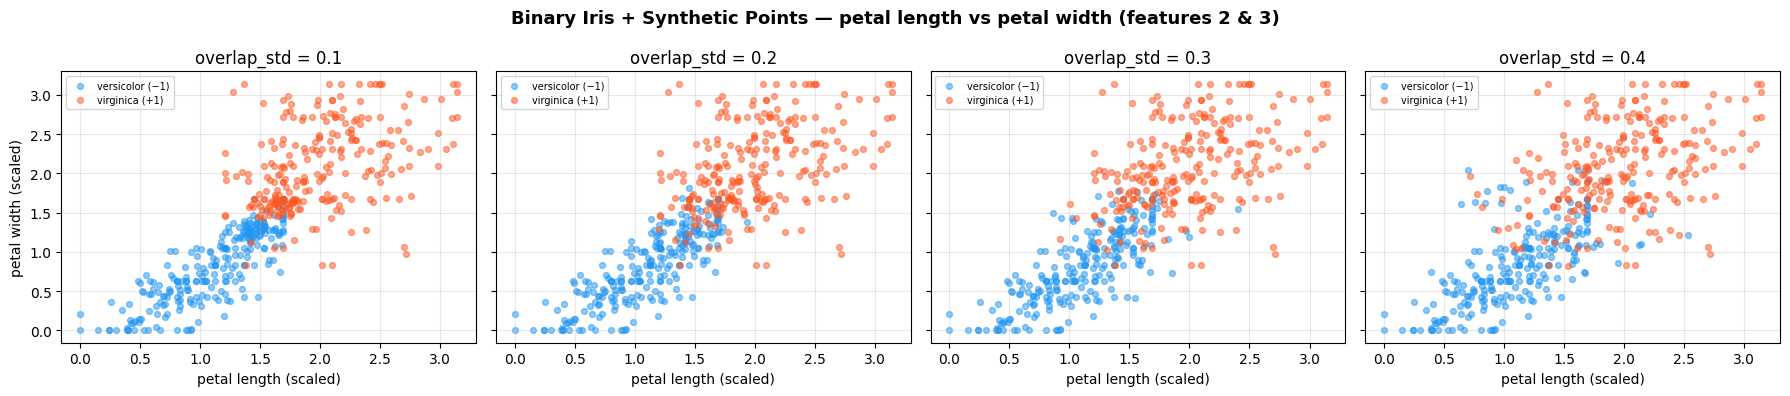

In [24]:
fig, axes = plt.subplots(1, len(OVERLAP_LEVELS), figsize=(18, 4), sharey=True)
fig.suptitle("Binary Iris + Synthetic Points — petal length vs petal width (features 2 & 3)",
             fontsize=13, fontweight='bold')

colors = {-1: "#2196F3", 1: "#FF5722"}
labels = {-1: "versicolor (−1)", 1: "virginica (+1)"}

for ax, std in zip(axes, OVERLAP_LEVELS):
    d = datasets[std]
    X_all = np.vstack([d["X_train"], d["X_test"]])
    y_all = np.concatenate([d["y_train"], d["y_test"]])

    # Original points (first 100 are the real Iris samples)
    for cls in [-1, 1]:
        idx = y_all == cls
        ax.scatter(X_all[idx, 2], X_all[idx, 3],
                   c=colors[cls], alpha=0.5, s=18, label=labels[cls])

    ax.set_title(f"overlap_std = {std}")
    ax.set_xlabel("petal length (scaled)")
    if ax == axes[0]:
        ax.set_ylabel("petal width (scaled)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Circuit Architecture

Same VQC as `iris_vqc_antinoise_v2`:
- **Data reuploading**: `AngleEmbedding + StronglyEntanglingLayers` repeated `N_LAYERS` times
- **Measurement**: ⟨Z₀⟩ → sign → predicted label {+1, −1}
- **Clean circuit**: `default.qubit`, `diff_method=best` (Parameter-Shift)  
- **Noisy circuit**: `qiskit.aer` with `ibm_fez` noise model, `SHOTS_HW=512`

Binary task means **one circuit per overlap level** (not 3 as in 1-vs-All).


Weight shape: (7, 4, 3)  (84 parameters)


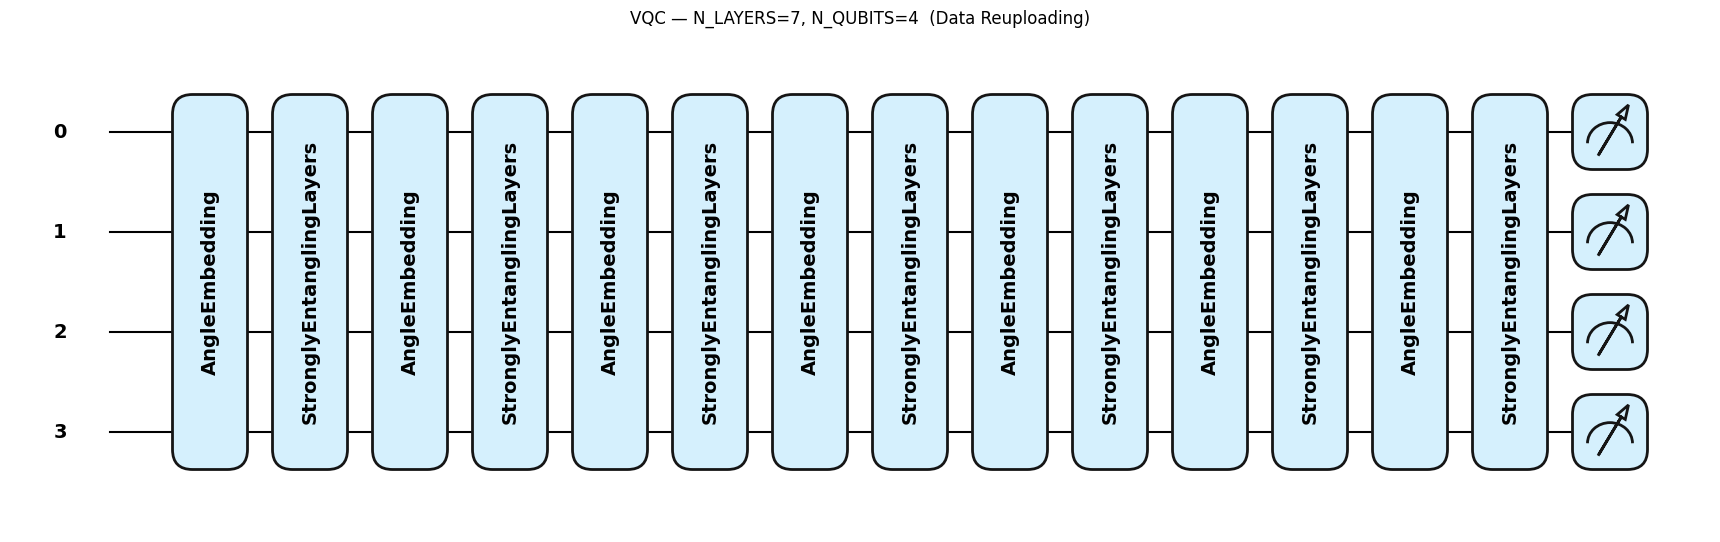

In [25]:
def create_vqc(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS,
               trainable=False, **device_kwargs):
    """
    trainable=True  → diff_method='best' (Parameter-Shift), for entrenamiento.
    trainable=False → without diff_method, for evaluation/mitiq.
    """
    device      = qml.device(device_name, wires=n_qubits, **device_kwargs)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
    kwargs = {"diff_method": "best"} if trainable else {}

    @qml.qnode(device, **kwargs)
    def circuit(inputs, weights):
        for layer_idx in range(n_layers):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers):
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliZ(2) @ qml.PauliZ(3))

    return circuit, weight_shape, device


# Instantiate circuits — one clean + one noisy (shared across overlap levels,
# only the dataset changes; the circuit topology is the same)
sim_circuit,   weight_shape, _      = create_vqc('default.qubit', trainable=True)
noisy_circuit, weight_shape, hw_dev = create_vqc(
    'qiskit.aer', trainable=False,
    shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)

print(f"Weight shape: {weight_shape}  ({np.prod(weight_shape)} parameters)")

# Draw circuit
dummy_w = np.zeros(weight_shape)
dummy_x = np.zeros(N_FEATURES)
fig, ax = qml.draw_mpl(sim_circuit, decimals=None, style="pennylane")(dummy_x, dummy_w)
ax.set_title(f"VQC — N_LAYERS={N_LAYERS}, N_QUBITS={N_QUBITS}  (Data Reuploading)")
plt.tight_layout()
plt.show()


## 6. Training

For each overlap level we train:
- **VQC (clean)**: Adam optimiser, `default.qubit`, Parameter-Shift gradients
- **SVM**: RBF kernel, `C=1.0`, `gamma=scale` — same train split

Models are cached to `models_overlap/` so re-running the notebook doesn't retrain.  
Cache key: `sim_overlap{std}_weights.npy` — delete to force retrain.


In [26]:
def mse_loss(predictions, targets):
    return np.mean((predictions - targets) ** 2)


def train_vqc(circuit, weight_shape, X_train, y_train,
              n_epochs=N_EPOCHS, lr=LEARNING_RATE,
              batch_size=BATCH_SIZE, label="",
              patience=8, min_delta=1e-4): 

    weights    = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    opt        = qml.AdamOptimizer(stepsize=lr)
    loss_curve = []
    n_samples  = len(X_train)

    # Early stopping state
    best_loss    = np.inf
    best_weights = weights.copy()
    no_improve   = 0

    for epoch in range(n_epochs):
        perm   = np.random.permutation(n_samples)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]
        epoch_losses = []

        for start in range(0, n_samples, batch_size):
            X_b = X_shuf[start:start + batch_size]
            y_b = y_shuf[start:start + batch_size]

            def batch_cost(w):
                preds = np.array([circuit(x, w) for x in X_b])
                return mse_loss(preds, y_b)

            weights, loss_val = opt.step_and_cost(batch_cost, weights)
            epoch_losses.append(float(loss_val))

        mean_loss = float(np.mean(epoch_losses))
        loss_curve.append(mean_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {mean_loss:.4f}")

        # Early stopping check
        if mean_loss < best_loss - min_delta:
            best_loss    = mean_loss
            best_weights = weights.copy()
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  [{label}] early stop at epoch {epoch+1}  best_loss: {best_loss:.4f}")
                return best_weights, loss_curve   # ← devuelve los mejores pesos, no los últimos

    return best_weights, loss_curve


def predict_binary(circuit, weights, X):
    scores = np.array([float(circuit(x, weights)) for x in X])
    return np.where(scores >= 0.0, 1, -1).astype(int)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1,  zero_division=0),
        "recall"   : recall_score(y_true, y_pred,    pos_label=1,  zero_division=0),
        "f1"       : f1_score(y_true, y_pred,         pos_label=1, zero_division=0),
    }


In [27]:
# Train VQC (clean) + SVM for every overlap level
vqc_weights  = {}   # overlap_std → trained weights
vqc_losses   = {}   # overlap_std → loss curve
svm_models   = {}   # overlap_std → fitted SVC

for std in OVERLAP_LEVELS:
    d      = datasets[std]
    tag = f"{int(std * 100):03d}" # e.g. "010", "015", "020", "025", "030"
    w_path = os.path.join(MODELS_DIR, f"sim_overlap{tag}_weights.npy")
    l_path = os.path.join(MODELS_DIR, f"sim_overlap{tag}_loss.json")

    print(f"\n{'─'*55}")
    print(f" overlap_std = {std}  ({d['n_total']} samples)")
    print(f"{'─'*55}")

    # VQC clean
    if os.path.exists(w_path):
        print("  VQC weights found — loading from disk.")
        weights    = np.load(w_path)
        with open(l_path) as f:
            loss_curve = json.load(f)
    else:
        weights, loss_curve = train_vqc(
            sim_circuit, weight_shape,
            d["X_train"], d["y_train"],
            label=f"sim/overlap={std}"
        )
        np.save(w_path, np.array(weights))
        with open(l_path, "w") as f:
            json.dump(loss_curve, f)
        print(f"  VQC saved → {w_path}")

    vqc_weights[std] = weights
    vqc_losses[std]  = loss_curve

    # SVM
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    svm.fit(d["X_train"], d["y_train"])
    svm_models[std] = svm
    svm_acc = accuracy_score(d["y_test"], svm.predict(d["X_test"]))
    print(f"  SVM test accuracy: {svm_acc:.3f}")

print("\nAll models ready.")



───────────────────────────────────────────────────────
 overlap_std = 0.1  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.987

───────────────────────────────────────────────────────
 overlap_std = 0.2  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.947

───────────────────────────────────────────────────────
 overlap_std = 0.3  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.913

───────────────────────────────────────────────────────
 overlap_std = 0.4  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.907

All models ready.


## 7. Evaluation

Three conditions per overlap level:

| Condition | Weights | Evaluation circuit | Expected behaviour |
|---|---|---|---|
| `sim → sim` | VQC clean | `default.qubit` | Upper bound — unaffected by noise |
| `sim → noisy` | VQC clean | `qiskit.aer` + noise | Degrades as overlap increases AND circuit noise matters |
| `SVM` | RBF kernel | Classical | Classical ceiling for comparison |

The **key signal** is the gap between `sim → sim` and `sim → noisy`.  
If that gap grows with overlap, it means the noise is crossing the decision boundary —
and that is exactly where mitigation techniques will be useful.


In [28]:
rows = []

for std in OVERLAP_LEVELS:
    d = datasets[std]
    y_true = d["y_test"].astype(int)

    # Condition 1: sim weights → sim eval
    y_pred_ss = predict_binary(sim_circuit, vqc_weights[std], d["X_test"])
    m = compute_metrics(y_true, y_pred_ss)
    m.update({"overlap": std, "condition": "sim → sim"})
    rows.append(m)

    # Condition 2: sim weights → noisy eval
    y_pred_sn = predict_binary(noisy_circuit, vqc_weights[std], d["X_test"])
    m = compute_metrics(y_true, y_pred_sn)
    m.update({"overlap": std, "condition": "sim → noisy"})
    rows.append(m)

    # Condition 3: SVM
    y_pred_svm = svm_models[std].predict(d["X_test"]).astype(int)
    m = compute_metrics(y_true, y_pred_svm)
    m.update({"overlap": std, "condition": "SVM"})
    rows.append(m)

    print(f"overlap={std}  sim→sim={rows[-3]['accuracy']:.3f}  "
          f"sim→noisy={rows[-2]['accuracy']:.3f}  "
          f"SVM={rows[-1]['accuracy']:.3f}  "
          f"Δ(noisy-sim)={rows[-2]['accuracy']-rows[-3]['accuracy']:+.3f}")

results_df = pd.DataFrame(rows)[["overlap","condition","accuracy","precision","recall","f1"]]
pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*70)
print(results_df.to_string(index=False))


overlap=0.1  sim→sim=0.980  sim→noisy=0.967  SVM=0.987  Δ(noisy-sim)=-0.013
overlap=0.2  sim→sim=0.933  sim→noisy=0.933  SVM=0.947  Δ(noisy-sim)=+0.000
overlap=0.3  sim→sim=0.887  sim→noisy=0.893  SVM=0.913  Δ(noisy-sim)=+0.007
overlap=0.4  sim→sim=0.867  sim→noisy=0.887  SVM=0.907  Δ(noisy-sim)=+0.020

 overlap   condition  accuracy  precision  recall    f1
   0.100   sim → sim     0.980      0.986   0.973 0.980
   0.100 sim → noisy     0.967      0.973   0.960 0.966
   0.100         SVM     0.987      0.987   0.987 0.987
   0.200   sim → sim     0.933      0.945   0.920 0.932
   0.200 sim → noisy     0.933      0.958   0.907 0.932
   0.200         SVM     0.947      0.947   0.947 0.947
   0.300   sim → sim     0.887      0.882   0.893 0.887
   0.300 sim → noisy     0.893      0.893   0.893 0.893
   0.300         SVM     0.913      0.908   0.920 0.914
   0.400   sim → sim     0.867      0.923   0.800 0.857
   0.400 sim → noisy     0.887      0.953   0.813 0.878
   0.400         SVM   

## 8. Visualisations

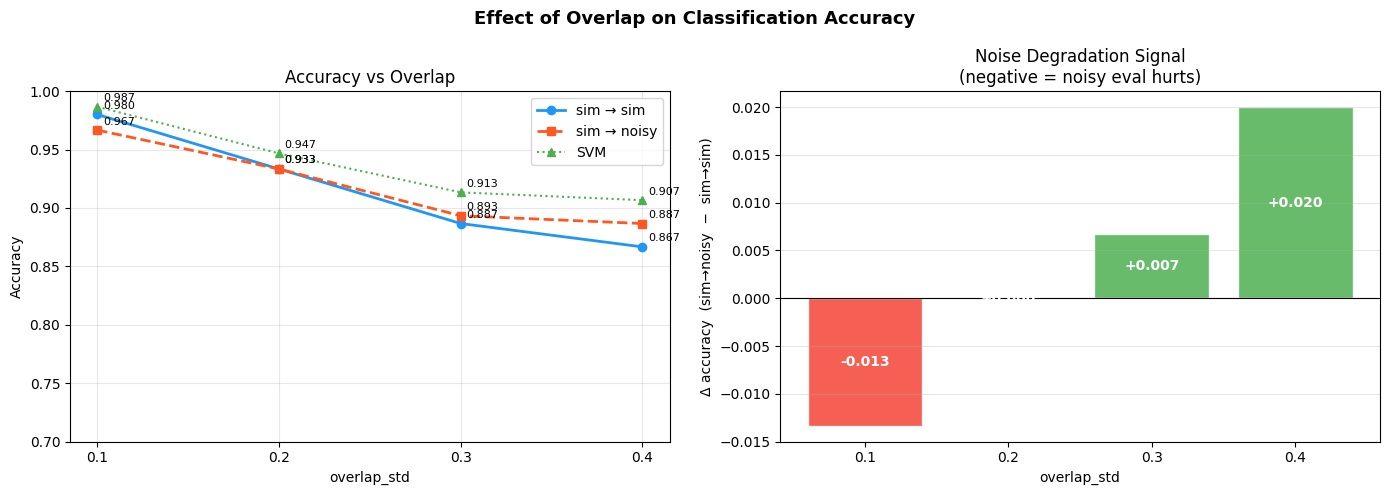

In [29]:
# 8.1 Accuracy vs overlap — main result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of Overlap on Classification Accuracy", fontsize=13, fontweight='bold')

condition_styles = {
    "sim → sim"  : {"color": "#2196F3", "marker": "o", "linestyle": "-",  "lw": 2.0},
    "sim → noisy": {"color": "#FF5722", "marker": "s", "linestyle": "--", "lw": 2.0},
    "SVM"        : {"color": "#4CAF50", "marker": "^", "linestyle": ":",  "lw": 1.5},
}

# Left: accuracy lines
ax = axes[0]
for cond, style in condition_styles.items():
    sub = results_df[results_df["condition"] == cond]
    ax.plot(sub["overlap"], sub["accuracy"],
            label=cond, **style)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['accuracy']:.3f}",
                    (row["overlap"], row["accuracy"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlabel("overlap_std")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Overlap")
ax.set_xticks(OVERLAP_LEVELS)
ax.set_ylim(0.7, 1.0)  
ax.legend()
ax.grid(alpha=0.3)

# Right: Δ accuracy (sim→noisy minus sim→sim) — noise degradation signal
ax = axes[1]
sim_sim   = results_df[results_df["condition"] == "sim → sim"  ].set_index("overlap")["accuracy"]
sim_noisy = results_df[results_df["condition"] == "sim → noisy"].set_index("overlap")["accuracy"]
delta     = sim_noisy - sim_sim

bar_colors = ["#4CAF50" if d >= 0 else "#F44336" for d in delta.values]
bars = ax.bar([str(s) for s in OVERLAP_LEVELS], delta.values,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, d in zip(bars, delta.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2, 
            f"{d:+.3f}", ha='center', va='center',
            fontsize=10, color='white', fontweight='bold') 
ax.set_xlabel("overlap_std")
ax.set_ylabel("Δ accuracy  (sim→noisy  −  sim→sim)")
ax.set_title("Noise Degradation Signal\n(negative = noisy eval hurts)")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

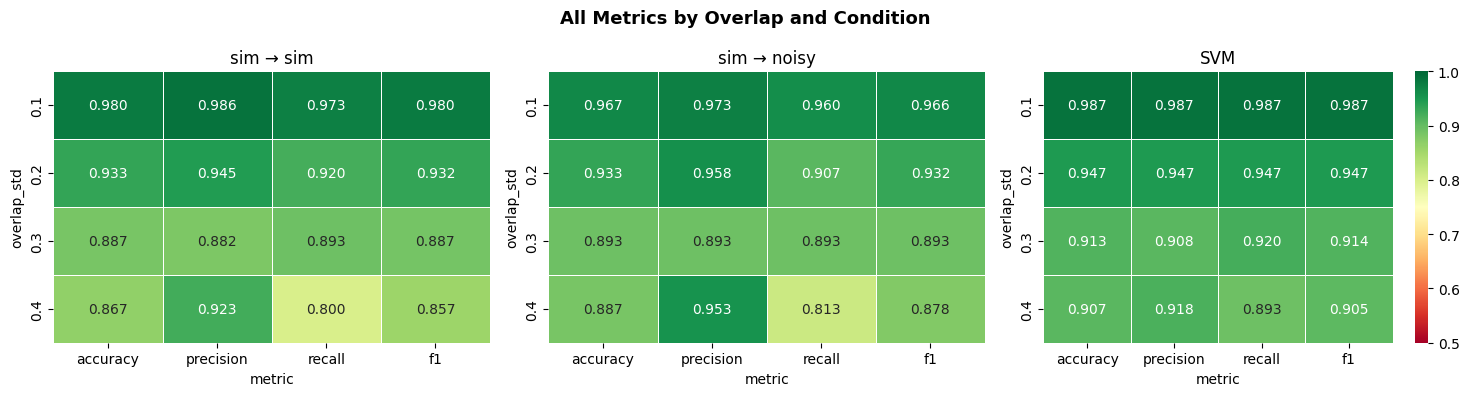

In [30]:
# 8.2 All metrics heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("All Metrics by Overlap and Condition", fontsize=13, fontweight='bold')

metrics = ["accuracy", "precision", "recall", "f1"]
for ax, cond in zip(axes, ["sim → sim", "sim → noisy", "SVM"]):
    sub   = results_df[results_df["condition"] == cond].set_index("overlap")[metrics]
    sns.heatmap(sub.astype(float), annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0.5, vmax=1.0,
                ax=ax, linewidths=0.5, cbar=(ax == axes[-1]))
    ax.set_title(cond)
    ax.set_xlabel("metric")
    ax.set_ylabel("overlap_std")

plt.tight_layout()
plt.show()


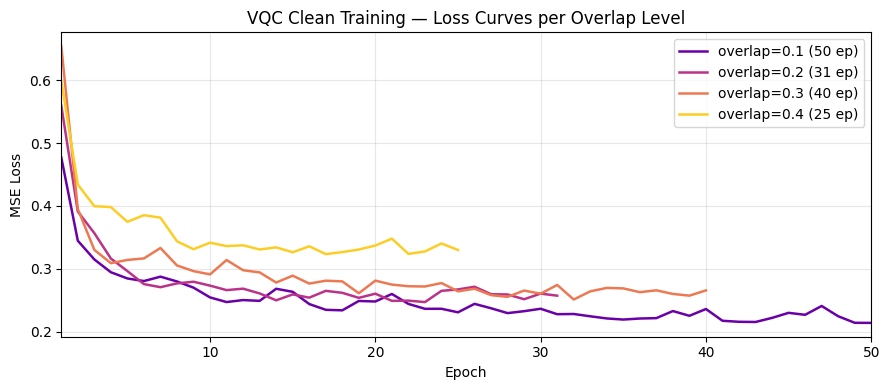

In [31]:
# 8.3 Loss curves — VQC clean training
fig, ax = plt.subplots(figsize=(9, 4))
palette = plt.cm.plasma(np.linspace(0.2, 0.9, len(OVERLAP_LEVELS)))

for std, color in zip(OVERLAP_LEVELS, palette):
    loss = vqc_losses[std]
    epochs_run = len(loss)                    
    ax.plot(range(1, epochs_run + 1), loss,
            label=f"overlap={std} ({epochs_run} ep)", color=color, linewidth=1.8)

ax.set_xlim(1, N_EPOCHS)     
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("VQC Clean Training — Loss Curves per Overlap Level")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


overlap=0.1  |⟨Z₀⟩| sim=0.601  noisy=0.319  ratio=0.530  Δ⟨Z₀⟩=-0.0091 ± 0.3034  MSE sim=0.2155  noisy=0.4819  ΔMSE=+0.2663
overlap=0.2  |⟨Z₀⟩| sim=0.586  noisy=0.306  ratio=0.513  Δ⟨Z₀⟩=+0.0130 ± 0.3022  MSE sim=0.2678  noisy=0.5225  ΔMSE=+0.2547
overlap=0.3  |⟨Z₀⟩| sim=0.586  noisy=0.314  ratio=0.537  Δ⟨Z₀⟩=+0.0141 ± 0.2954  MSE sim=0.3542  noisy=0.5634  ΔMSE=+0.2091
overlap=0.4  |⟨Z₀⟩| sim=0.575  noisy=0.306  ratio=0.530  Δ⟨Z₀⟩=+0.0371 ± 0.2889  MSE sim=0.3921  noisy=0.5913  ΔMSE=+0.1992


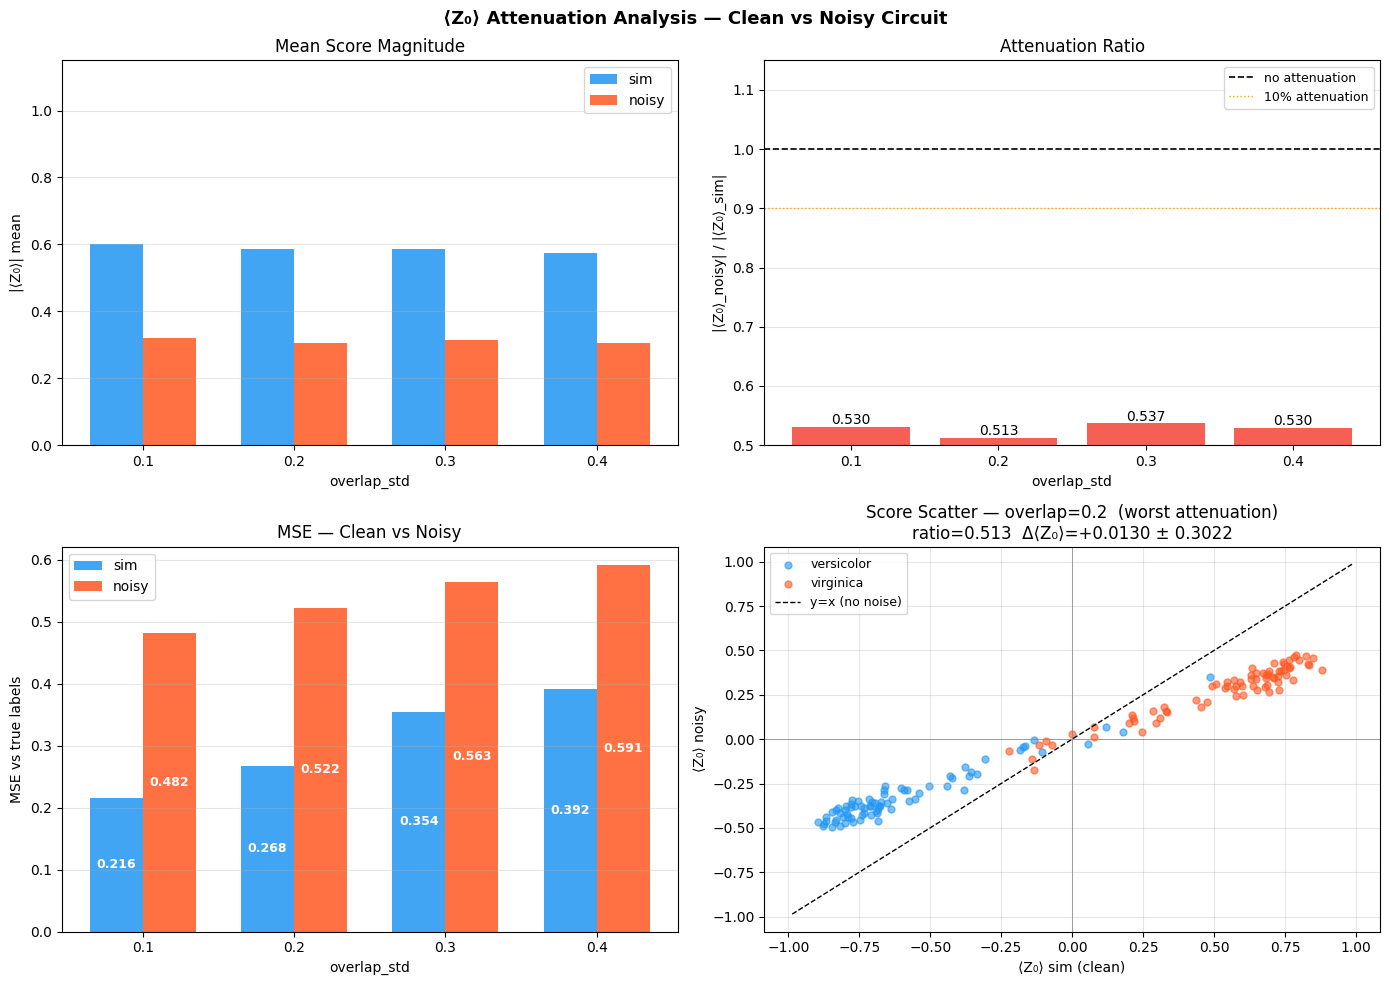

In [32]:
# Attenuation Analisis ⟨Z₀⟩
attenuation_rows = []

for std in OVERLAP_LEVELS:
    d = datasets[std]
    w = vqc_weights[std]

    scores_sim   = np.array([float(sim_circuit(x, w))   for x in d["X_test"]])
    scores_noisy = np.array([float(noisy_circuit(x, w)) for x in d["X_test"]])

    mask     = np.abs(scores_sim) > 0.05
    ratio    = np.abs(scores_noisy[mask]) / np.abs(scores_sim[mask])
    delta_z0 = scores_noisy - scores_sim

    mse_sim   = float(np.mean((scores_sim   - d["y_test"]) ** 2))
    mse_noisy = float(np.mean((scores_noisy - d["y_test"]) ** 2))

    attenuation_rows.append({
        "overlap"      : std,
        "mean_sim"     : float(np.mean(np.abs(scores_sim))),
        "mean_noisy"   : float(np.mean(np.abs(scores_noisy))),
        "mean_ratio"   : float(np.mean(ratio)),
        "mean_delta_z0": float(np.mean(delta_z0)),
        "std_delta_z0" : float(np.std(delta_z0)),
        "mse_sim"      : mse_sim,
        "mse_noisy"    : mse_noisy,
        "scores_sim"   : scores_sim,
        "scores_noisy" : scores_noisy,
        "y_test"       : d["y_test"],
    })
    print(f"overlap={std}  |⟨Z₀⟩| sim={attenuation_rows[-1]['mean_sim']:.3f}  "
          f"noisy={attenuation_rows[-1]['mean_noisy']:.3f}  "
          f"ratio={attenuation_rows[-1]['mean_ratio']:.3f}  "
          f"Δ⟨Z₀⟩={attenuation_rows[-1]['mean_delta_z0']:+.4f} ± {attenuation_rows[-1]['std_delta_z0']:.4f}  "
          f"MSE sim={mse_sim:.4f}  noisy={mse_noisy:.4f}  ΔMSE={mse_noisy - mse_sim:+.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("⟨Z₀⟩ Attenuation Analysis — Clean vs Noisy Circuit",
             fontsize=13, fontweight='bold')

# [0,0] Mean Score Magnitud |⟨Z₀⟩|
ax    = axes[0, 0]
x     = np.arange(len(OVERLAP_LEVELS))
bar_w = 0.35
means_s = [r["mean_sim"]   for r in attenuation_rows]
means_n = [r["mean_noisy"] for r in attenuation_rows]
ax.bar(x - bar_w/2, means_s, bar_w, label="sim",   color="#2196F3", alpha=0.85)
ax.bar(x + bar_w/2, means_n, bar_w, label="noisy", color="#FF5722", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in OVERLAP_LEVELS])
ax.set_xlabel("overlap_std")
ax.set_ylabel("|⟨Z₀⟩| mean")
ax.set_title("Mean Score Magnitude")
ax.set_ylim(0.0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# [0,1] Attenuation ratio
ax     = axes[0, 1]
ratios = [r["mean_ratio"] for r in attenuation_rows]
colors = ["#4CAF50" if r >= 0.95 else "#FF9800" if r >= 0.85 else "#F44336"
          for r in ratios]
bars = ax.bar([str(s) for s in OVERLAP_LEVELS], ratios, color=colors, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='no attenuation')
ax.axhline(0.9, color='orange', linestyle=':', linewidth=1.0, label='10% attenuation')
for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 0.005,
            f"{r:.3f}", ha='center', fontsize=10)
ax.set_xlabel("overlap_std")
ax.set_ylabel("|⟨Z₀⟩_noisy| / |⟨Z₀⟩_sim|")
ax.set_title("Attenuation Ratio")
ax.set_ylim(0.5, 1.15)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# [1,0] MSE sim vs noisy
ax    = axes[1, 0]
mse_s = [r["mse_sim"]   for r in attenuation_rows]
mse_n = [r["mse_noisy"] for r in attenuation_rows]
b1 = ax.bar(x - bar_w/2, mse_s, bar_w, label="sim",   color="#2196F3", alpha=0.85)
b2 = ax.bar(x + bar_w/2, mse_n, bar_w, label="noisy", color="#FF5722", alpha=0.85)
for bars_g, vals in [(b1, mse_s), (b2, mse_n)]:
    for bar, v in zip(bars_g, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"{v:.3f}", ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in OVERLAP_LEVELS])
ax.set_xlabel("overlap_std")
ax.set_ylabel("MSE vs true labels")
ax.set_title("MSE — Clean vs Noisy")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# [1,1] Scatter ⟨Z₀⟩ sim vs noisy
ax = axes[1, 1]
_worst_idx = int(np.argmin([r["mean_ratio"] for r in attenuation_rows]))
r          = attenuation_rows[_worst_idx]
for cls, color, name in [(-1, "#2196F3", "versicolor"), (1, "#FF5722", "virginica")]:
    idx = r["y_test"] == cls
    ax.scatter(r["scores_sim"][idx], r["scores_noisy"][idx],
               c=color, alpha=0.6, s=25, label=name)
lim = max(np.abs(r["scores_sim"]).max(), np.abs(r["scores_noisy"]).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1.0, label='y=x (no noise)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("⟨Z₀⟩ sim (clean)")
ax.set_ylabel("⟨Z₀⟩ noisy")
ax.set_title(f"Score Scatter — overlap={r['overlap']}  (worst attenuation)\n"
             f"ratio={r['mean_ratio']:.3f}  "
             f"Δ⟨Z₀⟩={r['mean_delta_z0']:+.4f} ± {r['std_delta_z0']:.4f}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Improve Model with biggest overlap 

In [33]:
# Select most negative noisy overlap Δ
sim_sim_acc   = results_df[results_df["condition"] == "sim → sim"  ].set_index("overlap")["accuracy"]
sim_noisy_acc = results_df[results_df["condition"] == "sim → noisy"].set_index("overlap")["accuracy"]
delta_acc     = sim_noisy_acc - sim_sim_acc

best_overlap = delta_acc.idxmin()
print(f"Overlap selected: {best_overlap}  (Δ accuracy = {delta_acc[best_overlap]:+.4f})")

d_best = datasets[best_overlap]
w_best = vqc_weights[best_overlap]
y_true = d_best["y_test"]

Overlap selected: 0.1  (Δ accuracy = -0.0133)


In [58]:
from qiskit      import QuantumCircuit
from qiskit      import ClassicalRegister
from qiskit_aer  import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.quantum_info   import SparsePauliOp
from mitiq import zne, pec
from mitiq.zne.scaling    import fold_gates_at_random, fold_global
from mitiq.zne.inference  import RichardsonFactory, LinearFactory
import mthree

# Observable global parity Z0⊗Z1⊗Z2⊗Z3
observable = SparsePauliOp("Z" * N_QUBITS)

# Execute once after defining sim_circuit:
_dummy_w = np.zeros(weight_shape)
_dummy_x = np.zeros(N_FEATURES)

# Extract ranges patron of StronglyEntanglingLayers
SEL_RANGES = list(range(1, N_QUBITS)) * (N_LAYERS // (N_QUBITS - 1) + 1)
SEL_RANGES = SEL_RANGES[:N_LAYERS]   # [1,2,3,1,2,3,1] para 4 qubits, 7 capas

def build_qiskit_vqc(weights, inputs, n_qubits=N_QUBITS, n_layers=N_LAYERS):
    """Reconstruct VQC as Qiskit circuit for mitiq.
    Use SEL_RANGES to replicate exactly the topology of StronglyEntanglingLayers.
    """
    qc = QuantumCircuit(n_qubits)
    w  = np.array(weights).reshape(n_layers, n_qubits, 3)

    for layer_idx in range(n_layers):
        # 1. AngleEmbedding: RY in all qubits
        for qubit, angle in enumerate(inputs):
            qc.ry(float(angle), qubit)

        # 2. Rotations Rot(phi,theta,omega) = RZ·RY·RZ in all qubits
        for qubit in range(n_qubits):
            qc.rz(float(w[layer_idx, qubit, 0]), qubit)
            qc.ry(float(w[layer_idx, qubit, 1]), qubit)
            qc.rz(float(w[layer_idx, qubit, 2]), qubit)

        # 3. CNOTs with Range
        r = SEL_RANGES[layer_idx]
        for qubit in range(n_qubits):
            qc.cx(qubit, (qubit + r) % n_qubits)
    return qc

backend_aer = AerSimulator(noise_model=noise_model)


def noisy_executor(qc):
    """Execute en noisy Aer y return ⟨Z0⊗Z1⊗Z2⊗Z3⟩."""
    estimator = AerEstimator()
    estimator.options.noise_model  = noise_model
    estimator.options.shots = SHOTS_HW
    estimator.options.seed_simulator = 42
    result = estimator.run([(qc, observable)]).result()
    return float(result[0].data.evs)


# Calibrate REM una once
print("Calibrating REM (mthree)...")
mit = mthree.M3Mitigation(backend_aer)
mit.cals_from_system(range(N_QUBITS), shots=SHOTS_HW)

Calibrating REM (mthree)...


In [59]:
# Comprobación: mismo sample, mismos pesos, comparar scores
x_test  = d_best["X_test"][0]
y_label = d_best["y_test"][0]

score_pennylane_clean = float(sim_circuit(x_test, w_best))
score_pennylane_noisy = float(noisy_circuit(x_test, w_best))
score_qiskit_noisy    = noisy_executor(build_qiskit_vqc(w_best, x_test))

print(f"label real         : {y_label:+.0f}")
print(f"PennyLane clean    : {score_pennylane_clean:+.4f}  → pred {'+1' if score_pennylane_clean >= 0 else '-1'}")
print(f"PennyLane noisy    : {score_pennylane_noisy:+.4f}  → pred {'+1' if score_pennylane_noisy >= 0 else '-1'}")
print(f"Qiskit noisy       : {score_qiskit_noisy:+.4f}  → pred {'+1' if score_qiskit_noisy >= 0 else '-1'}")

# Verificación adicional: circuito limpio via Qiskit sin noise model
from qiskit_aer import AerSimulator
backend_clean = AerSimulator()  # sin noise model

def clean_executor(qc):
    qc_m = qc.copy()
    qc_m.remove_final_measurements(inplace=True)
    qc_m.measure_all()
    counts = backend_clean.run(qc_m, shots=8192).result().get_counts()
    total  = sum(counts.values())
    return sum(
        (1 if bin(int(b, 2)).count('1') % 2 == 0 else -1) * n / total
        for b, n in counts.items()
    )

score_qiskit_clean = clean_executor(build_qiskit_vqc(w_best, x_test))
print(f"Qiskit clean       : {score_qiskit_clean:+.4f}  → pred {'+1' if score_qiskit_clean >= 0 else '-1'}")
print(f"\nDiferencia PL_clean vs Qiskit_clean : {abs(score_pennylane_clean - score_qiskit_clean):.4f}  {'✓ OK' if abs(score_pennylane_clean - score_qiskit_clean) < 0.05 else '✗ STILL WRONG'}")

label real         : +1
PennyLane clean    : +0.7582  → pred +1
PennyLane noisy    : +0.4023  → pred +1
Qiskit noisy       : +0.0822  → pred +1
Qiskit clean       : +0.0745  → pred +1

Diferencia PL_clean vs Qiskit_clean : 0.6838  ✗ STILL WRONG


In [60]:
# Ver ranges reales de cada capa de StronglyEntanglingLayers
w_full = np.zeros((N_LAYERS, N_QUBITS, 3))

tape = qml.tape.QuantumScript(
    [qml.StronglyEntanglingLayers(w_full.reshape(1, N_LAYERS, N_QUBITS, 3)[0], wires=range(N_QUBITS))],
    []
)
decomposed = tape.expand(depth=5)

layer_idx = -1
rot_count  = 0
print("Operaciones por capa:")
for op in decomposed.operations:
    if isinstance(op, qml.RZ) and op.wires[0] == 0:
        if rot_count % 2 == 0:  # primer RZ de qubit 0 = inicio de nueva capa
            layer_idx += 1
            print(f"\n--- Capa {layer_idx} ---")
        rot_count += 1
    if isinstance(op, qml.CNOT):
        print(f"  CNOT control={op.wires[0]} target={op.wires[1]}")

Operaciones por capa:

--- Capa 0 ---
  CNOT control=0 target=1
  CNOT control=1 target=2
  CNOT control=2 target=3
  CNOT control=3 target=0

--- Capa 1 ---
  CNOT control=0 target=2
  CNOT control=1 target=3
  CNOT control=2 target=0
  CNOT control=3 target=1

--- Capa 2 ---
  CNOT control=0 target=3
  CNOT control=1 target=0
  CNOT control=2 target=1
  CNOT control=3 target=2

--- Capa 3 ---
  CNOT control=0 target=1
  CNOT control=1 target=2
  CNOT control=2 target=3
  CNOT control=3 target=0

--- Capa 4 ---
  CNOT control=0 target=2
  CNOT control=1 target=3
  CNOT control=2 target=0
  CNOT control=3 target=1

--- Capa 5 ---
  CNOT control=0 target=3
  CNOT control=1 target=0
  CNOT control=2 target=1
  CNOT control=3 target=2

--- Capa 6 ---
  CNOT control=0 target=1
  CNOT control=1 target=2
  CNOT control=2 target=3
  CNOT control=3 target=0


In [51]:
# Define todas las techniques

def get_scores(predict_fn, weights, X):
    return np.array([predict_fn(weights, x) for x in X])

def score_to_pred(scores):
    return np.where(scores >= 0.0, 1, -1).astype(int)

def compute_all_metrics(scores, y_true, scores_ref):
    y_pred = score_to_pred(scores)
    mask   = np.abs(scores_ref) > 0.05
    ratio  = np.abs(scores[mask]) / np.abs(scores_ref[mask])
    return {
        "accuracy"   : accuracy_score(y_true.astype(int), y_pred),
        "precision"  : precision_score(y_true.astype(int), y_pred, zero_division=0),
        "recall"     : recall_score(y_true.astype(int), y_pred, zero_division=0),
        "f1"         : f1_score(y_true.astype(int), y_pred, zero_division=0),
        "mse"        : float(np.mean((scores - y_true) ** 2)),
        "mean_abs_z0": float(np.mean(np.abs(scores))),
        "attenuation": float(np.mean(ratio)),
    }


# Baseline noisy — without mitigation
def score_baseline(weights, x):
    return noisy_executor(build_qiskit_vqc(weights, x))

# REM
def score_rem(weights, x):
    qc = build_qiskit_vqc(weights, x)
    cr = ClassicalRegister(N_QUBITS, 'c')
    qc.add_register(cr)
    for i in range(N_QUBITS):
        qc.measure(i, cr[i])
    raw    = backend_aer.run(qc, shots=SHOTS_HW).result().get_counts()
    quasi  = mit.apply_correction(raw, range(N_QUBITS))
    # Global parity: +1 si número de |1⟩ es par, -1 si impar
    return sum(
        prob * (1 if bin(int(b, 2)).count('1') % 2 == 0 else -1)
        for b, prob in quasi.items()
    )

# ZNE global folding + Richardson
def score_zne(weights, x):
    qc = build_qiskit_vqc(weights, x)
    return zne.execute_with_zne(
        qc, executor=noisy_executor,
        factory=RichardsonFactory(scale_factors=[1, 2, 3]),
        scale_noise=fold_global,
    )

# Digital ZNE gate folding + Linear
def score_digital_zne(weights, x):
    qc = build_qiskit_vqc(weights, x)
    return zne.execute_with_zne(
        qc, executor=noisy_executor,
        factory=LinearFactory(scale_factors=[1, 3]),
        scale_noise=fold_gates_at_random,
    )

# REM + ZNE
def make_rem_executor():
    def executor(qc):
        # Copy only gates, ignore extras of ZNE
        qc_m = qc.copy()
        qc_m.remove_final_measurements(inplace=True)
        cr = ClassicalRegister(N_QUBITS, 'c')
        qc_m.add_register(cr)
        for i in range(N_QUBITS):
            qc_m.measure(i, cr[i])
        raw   = backend_aer.run(qc_m, shots=SHOTS_HW).result().get_counts()
        quasi = mit.apply_correction(raw, range(N_QUBITS))
        return sum(
            prob * (1 if bin(int(b, 2)).count('1') % 2 == 0 else -1)
            for b, prob in quasi.items()
        )
    return executor
def score_rem_zne(weights, x):
    qc = build_qiskit_vqc(weights, x)
    return zne.execute_with_zne(
        qc, executor=make_rem_executor(),
        factory=RichardsonFactory(scale_factors=[1, 2, 3]),
        scale_noise=fold_global,
    )

def score_rem_digital_zne(weights, x):
    qc = build_qiskit_vqc(weights, x)
    return zne.execute_with_zne(
        qc, executor=make_rem_executor(),
        factory=LinearFactory(scale_factors=[1, 3]),
        scale_noise=fold_gates_at_random,
    )

techniques = {
    "baseline"        : score_baseline,
    "REM"             : score_rem,
    "ZNE"             : score_zne,
    "Digital ZNE"     : score_digital_zne,
    "REM + ZNE"       : score_rem_zne,
    "REM + Digital ZNE": score_rem_digital_zne,
}

In [52]:
# Evaluate all techniques

scores_sim_ref = np.array([float(sim_circuit(x, w_best)) for x in d_best["X_test"]])
ref_metrics = compute_all_metrics(scores_sim_ref, y_true, scores_sim_ref)
ref_metrics["attenuation"] = 1.0  

mitigation_results = {"sim (ceiling)": ref_metrics}

for name, score_fn in techniques.items():
    print(f"\nEvaluating: {name}...")
    scores = get_scores(score_fn, w_best, d_best["X_test"])
    m = compute_all_metrics(scores, y_true, scores_sim_ref)
    mitigation_results[name] = m
    print(f"  acc={m['accuracy']:.3f}  f1={m['f1']:.3f}  "
          f"mse={m['mse']:.4f}  |Z0|={m['mean_abs_z0']:.3f}  "
          f"att={m['attenuation']:.3f}")

print(f"\n{'─'*60}")
print(f" sim (ceiling): acc={ref_metrics['accuracy']:.3f}  "
      f"f1={ref_metrics['f1']:.3f}  mse={ref_metrics['mse']:.4f}  "
      f"|Z0|={ref_metrics['mean_abs_z0']:.3f}")


Evaluating: baseline...
  acc=0.593  f1=0.527  mse=0.9437  |Z0|=0.217  att=0.496

Evaluating: REM...
  acc=0.593  f1=0.534  mse=0.9460  |Z0|=0.220  att=0.499

Evaluating: ZNE...
  acc=0.593  f1=0.527  mse=0.9437  |Z0|=0.217  att=0.496

Evaluating: Digital ZNE...
  acc=0.593  f1=0.527  mse=0.9437  |Z0|=0.217  att=0.496

Evaluating: REM + ZNE...
  acc=0.560  f1=0.450  mse=1.0474  |Z0|=0.266  att=0.544

Evaluating: REM + Digital ZNE...
  acc=0.587  f1=0.508  mse=0.9492  |Z0|=0.234  att=0.508

────────────────────────────────────────────────────────────
 sim (ceiling): acc=0.980  f1=0.980  mse=0.2155  |Z0|=0.601


In [53]:
# Diagnóstico: comparar un mismo sample entre los tres ejecutores
x_test  = d_best["X_test"][0]
y_label = d_best["y_test"][0]

score_pennylane_clean = float(sim_circuit(x_test, w_best))
score_pennylane_noisy = float(noisy_circuit(x_test, w_best))
score_qiskit_noisy    = noisy_executor(build_qiskit_vqc(w_best, x_test))

print(f"label real         : {y_label:+.0f}")
print(f"PennyLane clean    : {score_pennylane_clean:+.4f}  → pred {'+1' if score_pennylane_clean >= 0 else '-1'}")
print(f"PennyLane noisy    : {score_pennylane_noisy:+.4f}  → pred {'+1' if score_pennylane_noisy >= 0 else '-1'}")
print(f"Qiskit noisy       : {score_qiskit_noisy:+.4f}  → pred {'+1' if score_qiskit_noisy >= 0 else '-1'}")

label real         : +1
PennyLane clean    : +0.7582  → pred +1
PennyLane noisy    : +0.3516  → pred +1
Qiskit noisy       : +0.0822  → pred +1
